In [2]:
import pandas as pd
import numpy as np

# Load both year sheets
df1 = pd.read_excel(r"C:\Users\abhis\Downloads\online+retail+ii\online_retail_II.xlsx", sheet_name='Year 2009-2010')
df2 = pd.read_excel(r"C:\Users\abhis\Downloads\online+retail+ii\online_retail_II.xlsx", sheet_name='Year 2010-2011')

# Combine into one dataframe
df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)

(1067371, 8)


In [3]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [4]:
print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [5]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [6]:
# Rename for consistency
df.columns = ['Invoice', 'StockCode', 'Description', 'Quantity',
              'InvoiceDate', 'Price', 'CustomerID', 'Country']

# Drop rows with no CustomerID (guest checkouts — can't track churn)
print(f"Rows before: {len(df):,}")
df = df.dropna(subset=['CustomerID'])
print(f"Rows after dropping null CustomerID: {len(df):,}")

# Remove returns (Invoice starts with 'C' = cancellation)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"Rows after removing cancellations: {len(df):,}")

# Remove negative/zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f"Rows after removing bad quantities/prices: {len(df):,}")

# CustomerID as integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Ensure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Revenue column (the key metric)
df['Revenue'] = df['Quantity'] * df['Price']

print(f"\nFinal clean dataset: {len(df):,} rows")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Total revenue: £{df['Revenue'].sum():,.2f}")

Rows before: 1,067,371
Rows after dropping null CustomerID: 824,364
Rows after removing cancellations: 805,620
Rows after removing bad quantities/prices: 805,549

Final clean dataset: 805,549 rows
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5,878
Total revenue: £17,743,429.18


In [9]:
import sqlite3

conn = sqlite3.connect('C:/Users/abhis/Documents/Alex The Analyst/ecommerce-churn-analysis/data/cleaned/retail.db')
df.to_sql('retail_clean', conn, if_exists='replace', index=False)
conn.close()

# Also save CSV for Tableau
df.to_csv('C:/Users/abhis/Documents/Alex The Analyst/ecommerce-churn-analysis/data/cleaned/retail_clean.csv', index=False)
print("Exported to SQLite and CSV")

Exported to SQLite and CSV


RFM Segmentation

In [10]:
# Snapshot date = one day after last transaction
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

# Calculate R, F, M for each customer
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(rfm.describe())
print(f"\nTotal customers: {len(rfm):,}")

Snapshot date: 2011-12-10 12:50:00
         CustomerID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000

Total customers: 5,878


In [11]:
# Score each dimension 1–4
# Recency: lower days = better = score 4
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])

# Frequency & Monetary: higher = better = score 4
# Use rank to handle duplicates
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),
                          4, labels=[1, 2, 3, 4])

# Convert to int for comparison
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Assign segments
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalist'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    elif r == 1 and f >= 3:
        return 'At Risk'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Summary
segment_summary = rfm.groupby('Segment').agg(
    Customers    = ('CustomerID', 'count'),
    Avg_Recency  = ('Recency', 'mean'),
    Avg_Frequency= ('Frequency', 'mean'),
    Total_Revenue= ('Monetary', 'sum')
).round(1)

print(segment_summary.sort_values('Total_Revenue', ascending=False))

                    Customers  Avg_Recency  Avg_Frequency  Total_Revenue
Segment                                                                 
Champions                 774         10.7           22.2      9818880.6
Loyal                    1285         41.4            7.3      3797587.0
At Risk                   880        277.1            6.5      2221679.3
Potential Loyalist        894         40.7            1.8       769953.2
Cant Lose Them            270        362.6            2.1       558643.2
Others                   1041        332.8            1.7       397509.0
Lost                      734        541.3            1.0       179177.0


In [15]:
# Champions insight numbers
total_customers = len(rfm)
total_revenue = rfm['Monetary'].sum()

champions = rfm[rfm['Segment'] == 'Champions']
champions_customers = len(champions)
champions_revenue = champions['Monetary'].sum()

champ_customer_pct = (champions_customers / total_customers) * 100
champ_revenue_pct = (champions_revenue / total_revenue) * 100

print(f"Total customers: {total_customers:,}")
print(f"Total revenue: £{total_revenue:,.2f}")
print(f"Champions customers: {champions_customers:,}")
print(f"Champions revenue: £{champions_revenue:,.2f}")
print(f"Champions = {champ_customer_pct:.1f}% of customers")
print(f"Champions = {champ_revenue_pct:.1f}% of revenue")

# At Risk numbers for Dashboard 4 text
at_risk = rfm[rfm['Segment'] == 'At Risk']
print(f"\nAt Risk customers: {len(at_risk):,}")
print(f"At Risk revenue: £{at_risk['Monetary'].sum():,.2f}")

Total customers: 5,878
Total revenue: £17,743,429.18
Champions customers: 774
Champions revenue: £9,818,880.57
Champions = 13.2% of customers
Champions = 55.3% of revenue

At Risk customers: 880
At Risk revenue: £2,221,679.29


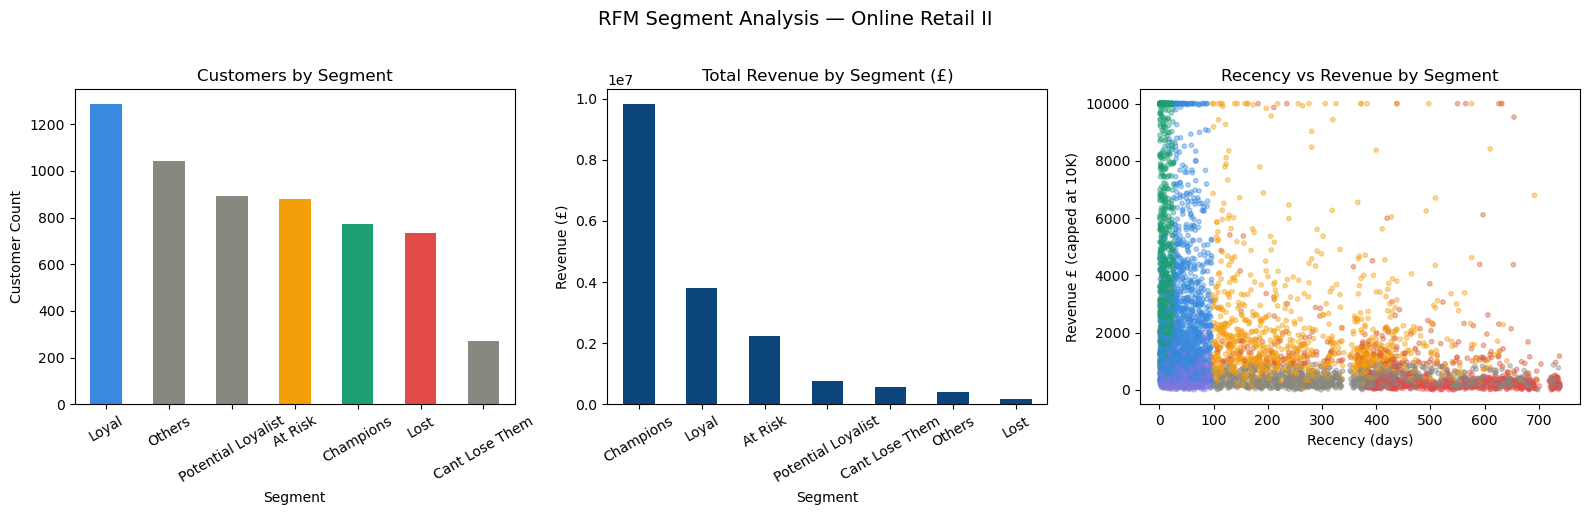

Saved rfm_plots.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('data/cleaned', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Segment Analysis — Online Retail II', fontsize=14, y=1.02)

# Plot 1: Customer count by segment
segment_counts = rfm['Segment'].value_counts()
colors = ['#1D9E75' if s == 'Champions' else
          '#378ADD' if s == 'Loyal' else
          '#F59E0B' if s == 'At Risk' else
          '#E24B4A' if s == 'Lost' else '#888780'
          for s in segment_counts.index]
segment_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Customers by Segment')
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Revenue by segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_revenue.plot(kind='bar', ax=axes[1], color='#0C447C')
axes[1].set_title('Total Revenue by Segment (£)')
axes[1].set_ylabel('Revenue (£)')
axes[1].tick_params(axis='x', rotation=30)

# Plot 3: RFM scatter — Recency vs Monetary
scatter_colors = rfm['Segment'].map({
    'Champions': '#1D9E75', 'Loyal': '#378ADD',
    'At Risk': '#F59E0B', 'Lost': '#E24B4A',
    'Potential Loyalist': '#7F77DD',
    'Cant Lose Them': '#D85A30', 'Others': '#888780'
})
axes[2].scatter(rfm['Recency'], rfm['Monetary'].clip(0, 10000),
                c=scatter_colors, alpha=0.4, s=10)
axes[2].set_title('Recency vs Revenue by Segment')
axes[2].set_xlabel('Recency (days)')
axes[2].set_ylabel('Revenue £ (capped at 10K)')

plt.tight_layout()
plt.savefig('data/cleaned/rfm_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved rfm_plots.png")

In [14]:
# Export RFM table
rfm.to_csv('C:/Users/abhis/Documents/Alex The Analyst/ecommerce-churn-analysis/data/cleaned/rfm_segments.csv', index=False)

# Export cohort data from SQL query (load the CSV saved from DB Browser)
# save it as cohort_retention.csv from DB Browser:
cohort = pd.read_csv('C:/Users/abhis/Documents/Alex The Analyst/ecommerce-churn-analysis/data/cleaned/cohort_retention.csv')
print("Files ready for Tableau:")
print("  - retail_clean.csv      (transactions)")
print("  - rfm_segments.csv      (RFM scores + segments)")
print("  - cohort_retention.csv  (cohort data for heatmap)")

Files ready for Tableau:
  - retail_clean.csv      (transactions)
  - rfm_segments.csv      (RFM scores + segments)
  - cohort_retention.csv  (cohort data for heatmap)
